<h1 style="color:#F0B4B4; font-size:32px;">Import modules</h1>

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path

<h1 style="color:#F0B4B4; font-size:32px;">Loading datasets</h1>

In [34]:
directory = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing/app/data/cleaned_data/extranat/competitions_per_type")

data = []

for file in directory.rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data.append(json.load(f))

# Aplatir les données : 1 ligne par performance
rows = []
for comp in data:
    for epreuve in comp.get("epreuves", []):
        for perf in epreuve.get("performances", []):

            # S'assurer que 'swimmer' est toujours une liste
            swimmers = perf.get("swimmer", [])
            if isinstance(swimmers, dict):
                swimmers = [swimmers]

            row = {
                "Meet": comp.get("Meet"),
                "SwimDate": comp.get("SwimDate"),
                "Location": comp.get("location"),
                "Country": comp.get("Country"),
                "Event": epreuve.get("Event"),
                "Distance": epreuve.get("Distance"),
                "Stroke": epreuve.get("Stroke"),
                "Course": epreuve.get("Course"),
                "PoolLength": epreuve.get("PoolLength"),
                "Tour": epreuve.get("tour"),
                "Rank": perf.get("Rank"),
                "Club": perf.get("club"),
                "points": perf.get("points"),
                "mpp": perf.get("mpp"),
                "mpp_date": perf.get("mpp_date"),
                "SwimTime": perf.get("SwimTime"),
                "SwimTimeSeconds": perf.get("SwimTimeSeconds"),
                "Status": perf.get("Status"),
                "Speed": perf.get("Speed"),
                "swimmer": swimmers, 
                "splits": perf.get("splits", [])
            }

            rows.append(row)

df = pd.DataFrame(rows)

print(df.head())
print("Nombre de SwimTime :", df['SwimTime'].notna().sum())

                                            Meet    SwimDate   Location  \
0  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
1  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
2  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
3  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
4  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   

  Country       Event  Distance Stroke Course  PoolLength    Tour  ...  \
0     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
1     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
2     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
3     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
4     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   

             Club points       mpp    mpp_date  SwimTime SwimTimeSeconds  \
0  MAINE-ET-LOIRE  930.0  02

In [5]:
print(df.columns)

Index(['Meet', 'SwimDate', 'Location', 'Country', 'Event', 'Distance',
       'Stroke', 'Course', 'PoolLength', 'Tour', 'Rank', 'Club', 'points',
       'mpp', 'mpp_date', 'SwimTime', 'SwimTimeSeconds', 'Status', 'Speed',
       'swimmer', 'splits'],
      dtype='object')


In [6]:
print("Nombre de lignes :", df.shape[0])  # 762371

Nombre de lignes : 762371


In [7]:
nb_swimtime_vides = df['SwimTime'].isna().sum()
print("Nombre de SwimTime vides :", nb_swimtime_vides)
# Nombre de SwimTime non vides
nb_swimtime = df['SwimTime'].notna().sum()
print("Nombre de SwimTime présents :", nb_swimtime)

Nombre de SwimTime vides : 0
Nombre de SwimTime présents : 762371


In [8]:
import pprint
pprint.pprint(df.iloc[383]["swimmer"])

[{'Gender': 'F',
  'Name': 'Rey Mia',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Gender': 'F',
  'Name': 'Lebas Romane Adèle',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Gender': 'F',
  'Name': 'Hoareau Miotysoa',
  'Nationality': 'FRA',
  'Year_of_birth': 2012},
 {'Gender': 'F',
  'Name': 'Daïca Dalleau Apryl',
  'Nationality': 'FRA',
  'Year_of_birth': 2012}]


In [9]:
print(df.iloc[383])

Meet                   Phase finale Coupe de France des Départements
SwimDate                                                  2025-12-22
Location                                                   DUNKERQUE
Country                                                          FRA
Event                                                     200 MD SCM
Distance                                                         200
Stroke                                                            MD
Course                                                           SCM
PoolLength                                                        25
Tour                                                          Séries
Rank                                                             1.0
Club                                                      LA RÉUNION
points                                                        1080.0
mpp                                                             None
mpp_date                          

In [10]:
import pprint
pprint.pprint(df.iloc[383]["splits"])

[{'cumul_seconds': 33.7,
  'split_distance': '50 m',
  'split_seconds': 33.7,
  'split_speed': 1.4837,
  'split_time': '00:33.70',
  'split_time_cumul': '33.70'},
 {'cumul_seconds': 71.4,
  'split_distance': '100 m',
  'split_seconds': 37.7,
  'split_speed': 2.6525,
  'split_time': '00:37.70',
  'split_time_cumul': '1:11.40'},
 {'cumul_seconds': 103.45,
  'split_distance': '150 m',
  'split_seconds': 32.05,
  'split_speed': 4.6802,
  'split_time': '00:32.05',
  'split_time_cumul': '1:43.45'},
 {'cumul_seconds': 132.02,
  'split_distance': '200 m',
  'split_seconds': 28.57,
  'split_speed': 7.0004,
  'split_time': '00:28.57',
  'split_time_cumul': '2:12.02'}]


<h1 style="color:#F0B4B4; font-size:32px;">Histogram of swim times</h1>

Nombre de performances pour l'event 50 FR LCM: 46419


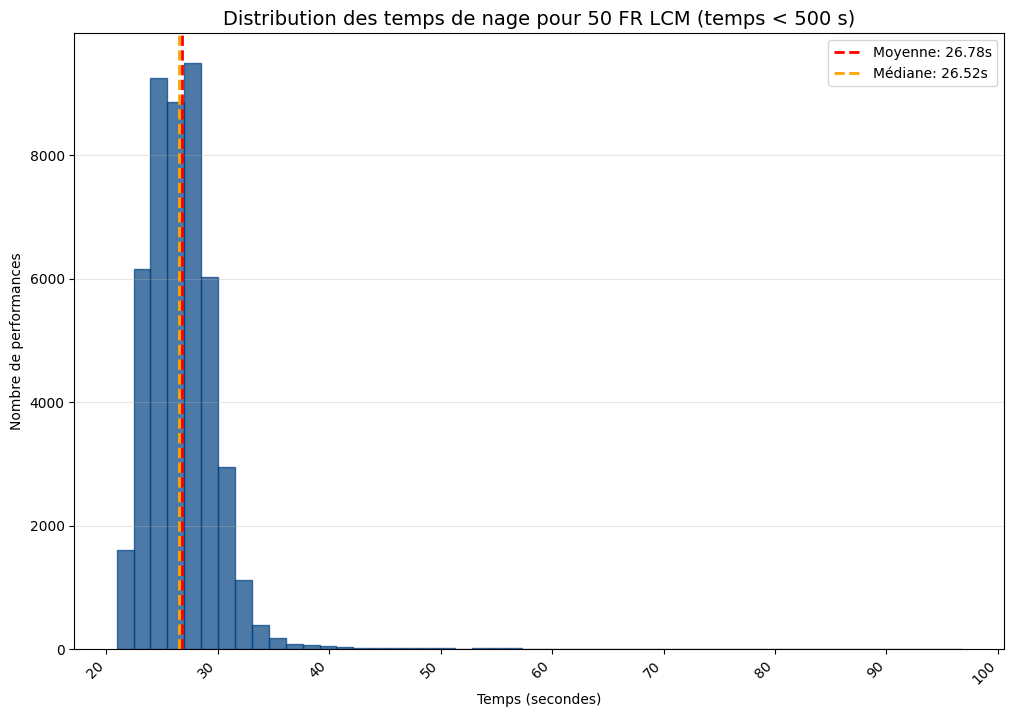

In [83]:
from matplotlib.ticker import MaxNLocator

nom_event = "50 FR LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) & 
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
].dropna()

print(f"Nombre de performances pour l'event {nom_event}: {len(swim_times)}")

fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(swim_times, bins=50, color="#004080", edgecolor="#004080", alpha=0.7)

mean_time = np.mean(swim_times)
median_time = np.median(swim_times)

ax.axvline(mean_time, color='red', linestyle='dashed', linewidth=2,
           label=f'Moyenne: {mean_time:.2f}s')
ax.axvline(median_time, color='orange', linestyle='dashed', linewidth=2,
           label=f'Médiane: {median_time:.2f}s')

ax.set_title(f"Distribution des temps de nage pour {nom_event} (temps < 500 s)", fontsize=14)
ax.set_xlabel("Temps (secondes)")
ax.set_ylabel("Nombre de performances")
ax.legend()

ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Histogram with Kernel Density Estimate (KDE)</h1>

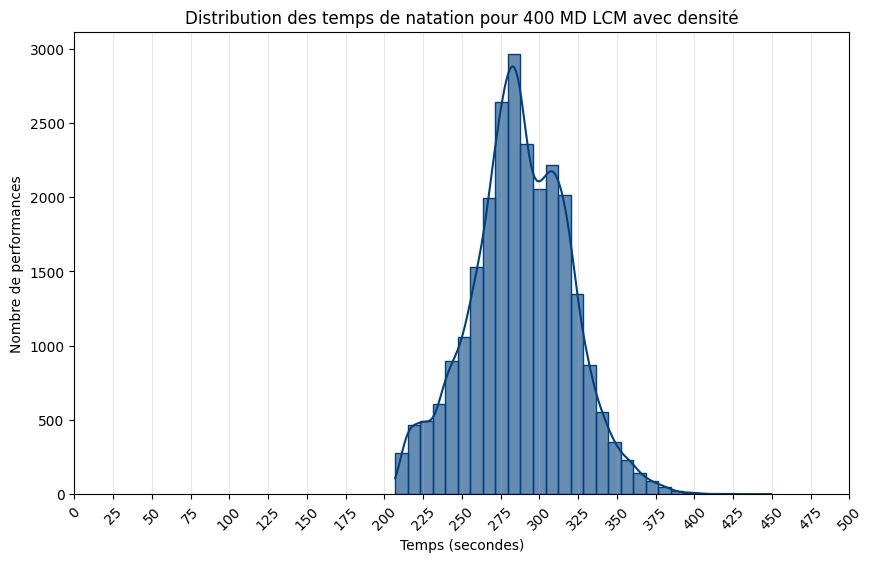

In [24]:
nom_event = "400 MD LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) & 
    (df["SwimTimeSeconds"].notna()) & 
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
]

plt.figure(figsize=(10,6))

sns.histplot(
    swim_times,
    bins=30,
    kde=True,
    color="#004080",
    edgecolor="#004080",
    alpha=0.6
)

plt.title(f"Distribution des temps de natation pour {nom_event} avec densité")
plt.xlabel("Temps (secondes)")
plt.ylabel("Nombre de performances")

plt.xticks(np.arange(0, 501, 25), rotation=45)
plt.grid(axis="x", alpha=0.3)

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Cumulative Histogram</h1>

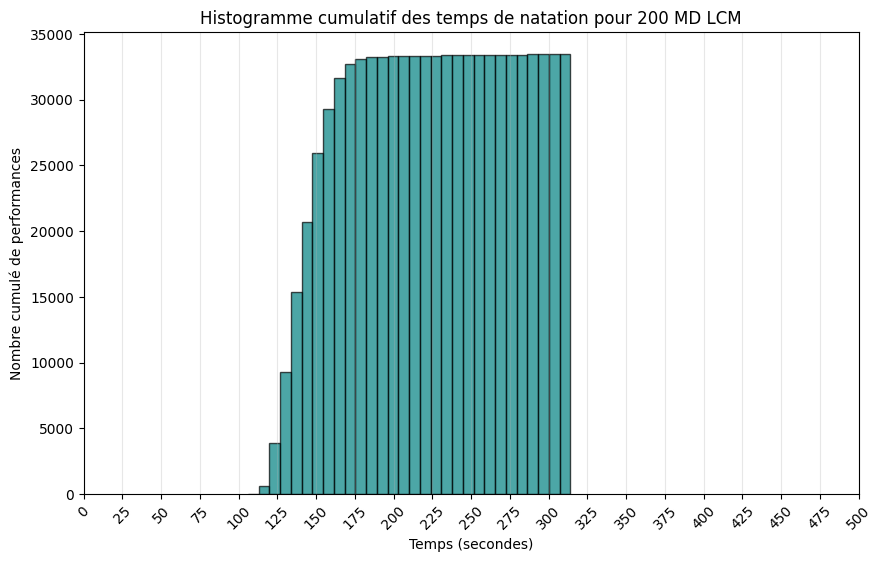

In [88]:
nom_event = "200 MD LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) &
    (df["SwimTimeSeconds"].notna()) &
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
]

if len(swim_times) > 0:
    plt.figure(figsize=(10,6))

    plt.hist(
        swim_times,
        bins=30,
        cumulative=True,
        color="#008080",
        edgecolor="black",
        alpha=0.7
    )

    plt.title(f"Histogramme cumulatif des temps de natation pour {nom_event}")
    plt.xlabel("Temps (secondes)")
    plt.ylabel("Nombre cumulé de performances")

    plt.xticks(np.arange(0, 501, 25), rotation=45)
    plt.grid(axis="x", alpha=0.3)

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

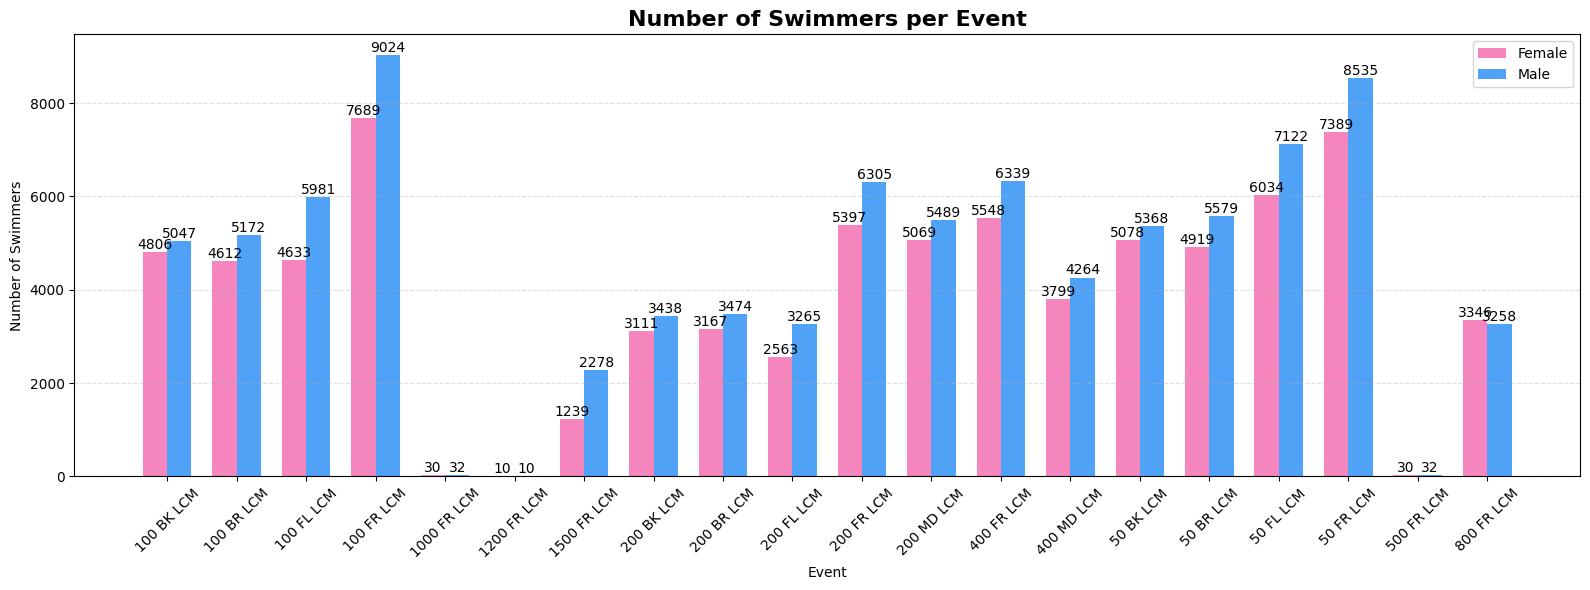

In [8]:
df["Gender"] = df["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

df["swimmer_name"] = df["swimmer"].apply(
    lambda x: x[0]["Name"] if isinstance(x, list) and len(x) > 0 else None
)

df_clean = df.dropna(subset=["Gender", "Event", "swimmer_name"])

df_clean = df_clean[df_clean["Event"].str.contains("LCM")]

df_counts = (
    df_clean
    .groupby(["Event", "Gender"])["swimmer_name"]
    .nunique()
    .unstack(fill_value=0)
)

df_counts = df_counts.sort_index()

events = df_counts.index
female_counts = df_counts.get("F", [0]*len(events))
male_counts = df_counts.get("M", [0]*len(events))

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(16,6))

bars1 = plt.bar(x - width/2, female_counts, width, 
                label="Female", color="#F585BD")

bars2 = plt.bar(x + width/2, male_counts, width, 
                label="Male", color="#4FA2F6")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.1,
            f"{int(height)}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title("Number of Swimmers per Event", fontsize=16, fontweight="bold")
plt.xlabel("Event")
plt.ylabel("Number of Swimmers")
plt.xticks(x, events, rotation=45)
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

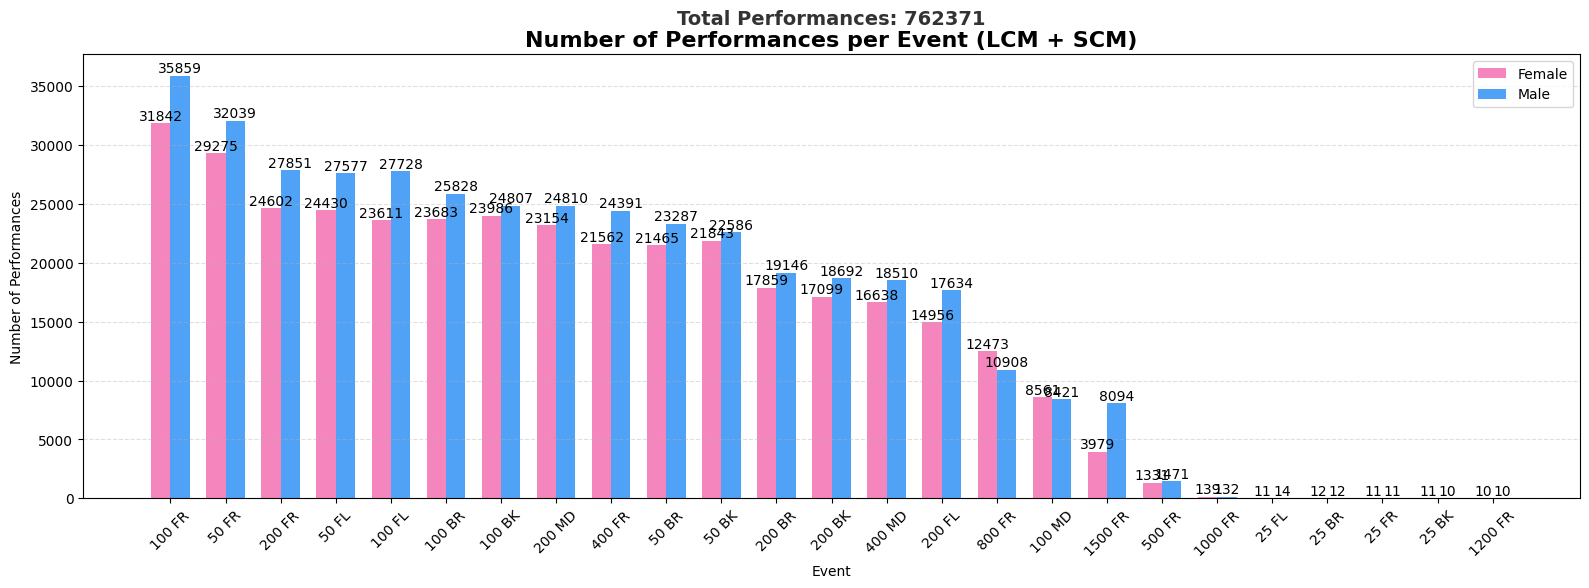

In [14]:
df["Gender"] = df["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

df["Event_clean"] = df["Event"].str.replace(" LCM", "", regex=False)\
                               .str.replace(" SCM", "", regex=False)

df_clean = df.dropna(subset=["Gender", "Event_clean"])

df_counts = (
    df_clean
    .groupby(["Event_clean", "Gender"])
    .size()
    .unstack(fill_value=0)
)

df_counts["Total"] = df_counts.sum(axis=1)
df_counts = df_counts.sort_values("Total", ascending=False).drop(columns="Total")

total_performances = df_counts.sum().sum()

events = df_counts.index
female_counts = df_counts.get("F", [0]*len(events))
male_counts = df_counts.get("M", [0]*len(events))

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(16,6))

bars1 = plt.bar(x - width/2, female_counts, width, 
                label="Female", color="#F585BD")

bars2 = plt.bar(x + width/2, male_counts, width, 
                label="Male", color="#4FA2F6")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.1,
            f"{int(height)}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title("Number of Performances per Event (LCM + SCM)", fontsize=16, fontweight="bold")

plt.text(
    0.5, 1.08,
    f"Total Performances: {int(total_performances)}",
    ha='center',
    va='center',
    transform=plt.gca().transAxes,
    fontsize=14,
    fontweight='bold',
    color="#333333"
)

plt.xlabel("Event")
plt.ylabel("Number of Performances")
plt.xticks(x, events, rotation=45)
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Countplot number of performances by sex</h1>

Gender
M    399828
F    362543
Name: count, dtype: int64


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2908/3315299978.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette=palette_colors)


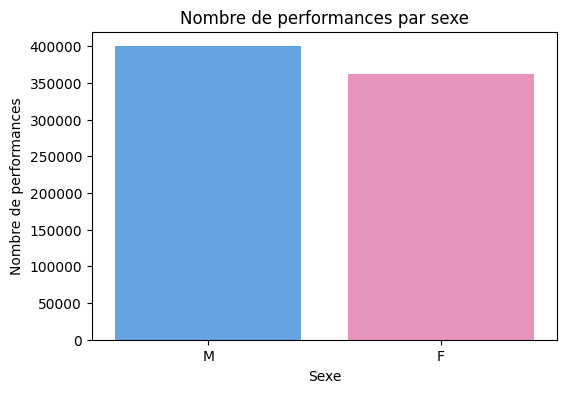

In [13]:
df["Gender"] = df["swimmer"].apply(lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None)

print(df["Gender"].value_counts())

plt.figure(figsize=(6,4))

palette_colors = {
    "F": "#F585BD",
    "M": "#4FA2F6"
}

sns.countplot(x="Gender", data=df, palette=palette_colors)

plt.title("Nombre de performances par sexe")
plt.xlabel("Sexe")
plt.ylabel("Nombre de performances")

plt.show()

Gender
M    1667
F     614
Name: count, dtype: int64


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2633/3549769266.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df_event, palette=palette_colors)


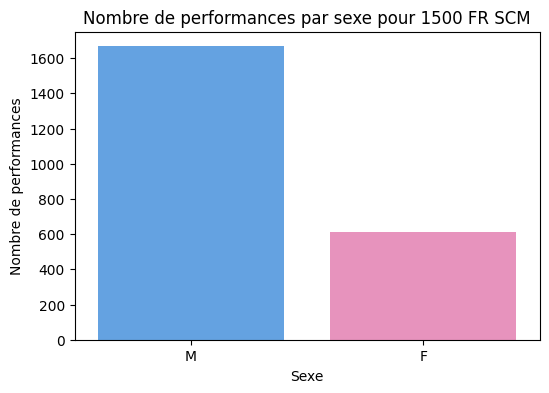

In [90]:
nom_event = "1500 FR SCM"

df_event = df[df["Event"] == nom_event].copy()

df_event["Gender"] = df_event["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

print(df_event["Gender"].value_counts())

plt.figure(figsize=(6,4))

palette_colors = {
    "F": "#F585BD",
    "M": "#4FA2F6"
}

sns.countplot(x="Gender", data=df_event, palette=palette_colors)

plt.title(f"Nombre de performances par sexe pour {nom_event}")
plt.xlabel("Sexe")
plt.ylabel("Nombre de performances")

plt.show()

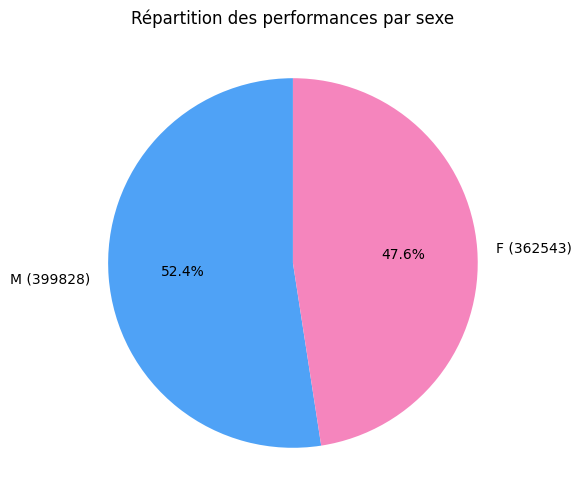

In [14]:
gender_counts = df["Gender"].value_counts()

colors = ["#4FA2F6","#F585BD"]

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=[f"{g} ({n})" for g, n in zip(gender_counts.index, gender_counts)],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Répartition des performances par sexe")

plt.show()

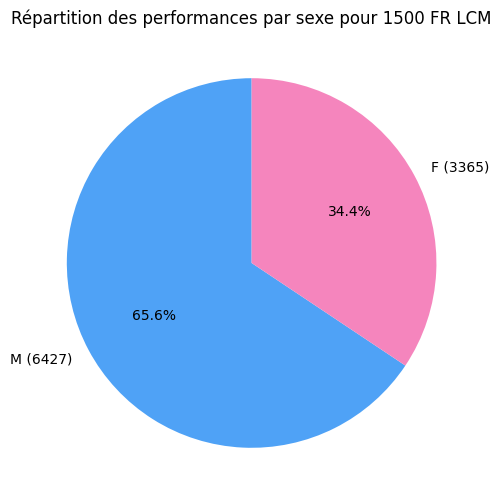

In [91]:
nom_event = "1500 FR LCM"

df_event = df[df["Event"] == nom_event].copy()

df_event["Gender"] = df_event["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

gender_counts = df_event["Gender"].value_counts()

if len(gender_counts) > 0:
    colors = ["#4FA2F6", "#F585BD"]

    plt.figure(figsize=(6,6))

    plt.pie(
        gender_counts,
        labels=[f"{g} ({n})" for g, n in zip(gender_counts.index, gender_counts)],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90
    )

    plt.title(f"Répartition des performances par sexe pour {nom_event}")
    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

In [18]:
print(df['Stroke'].unique()) # ['FR', 'BK', 'BR', 'FL', 'MD']

['FR' 'BK' 'BR' 'FL' 'MD']


<h1 style="color:#F0B4B4; font-size:32px;">Barplot of average time per swimming stroke and distance</h1>

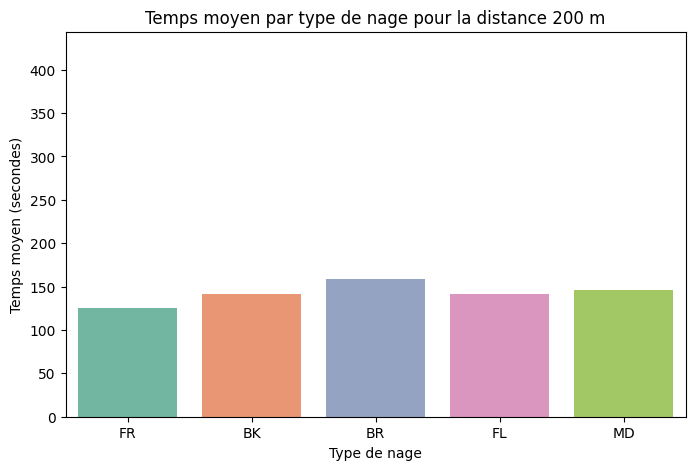

In [77]:
distance_choisie = 200

subset = df[
    (df['SwimTimeSeconds'].notna()) &
    (df['Distance'] == distance_choisie)
]

if len(subset) > 0:
    plt.figure(figsize=(8,5))
    sns.barplot(
        x='Stroke',
        y='SwimTimeSeconds',
        data=subset,
        hue='Stroke',
        palette="Set2",
        errorbar=None,
        dodge=False
    )

    plt.title(f"Temps moyen par type de nage pour la distance {distance_choisie} m")
    plt.xlabel("Type de nage")
    plt.ylabel("Temps moyen (secondes)")
    plt.ylim(0, subset['SwimTimeSeconds'].max() + 5)

    plt.show()
else:
    print(f"Aucune donnée disponible pour la distance {distance_choisie} m")

<h1 style="color:#F0B4B4; font-size:32px;">Bar Chart: Number of Performances per Club</h1>

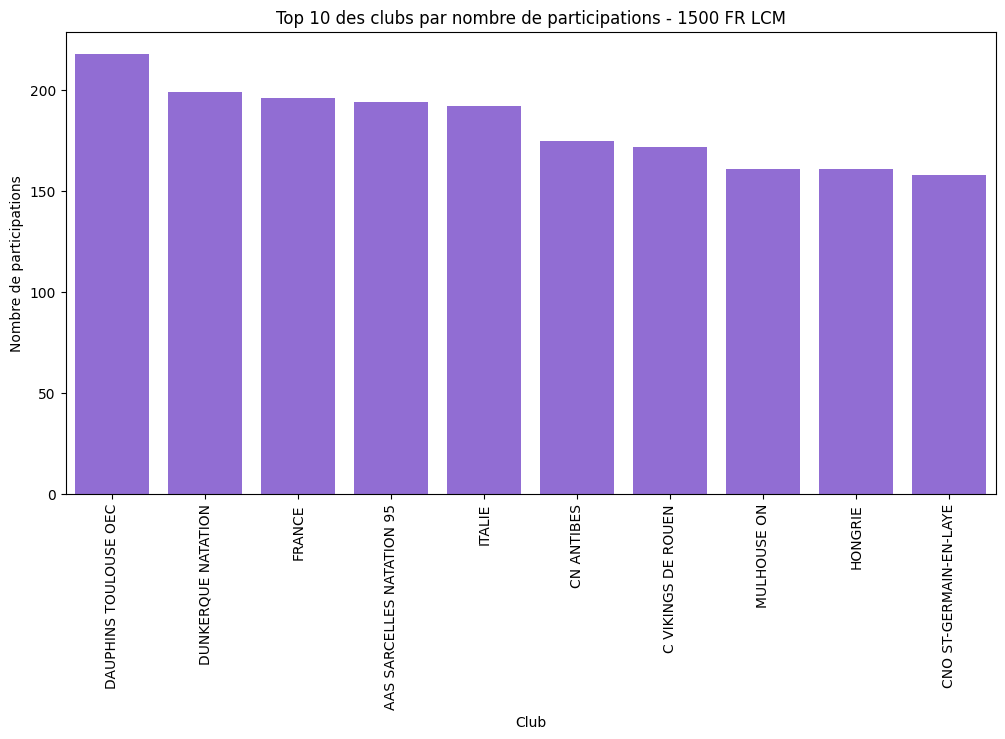

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

nom_event = "1500 FR LCM"

df_event = df[df["Event"] == nom_event]

top_clubs = df_event["Club"].value_counts().nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_clubs.index, y=top_clubs.values, color="#8C5CE4")

plt.title(f"Top 10 des clubs par nombre de participations - {nom_event}")
plt.xlabel("Club")
plt.ylabel("Nombre de participations")
plt.xticks(rotation=90)

plt.show()

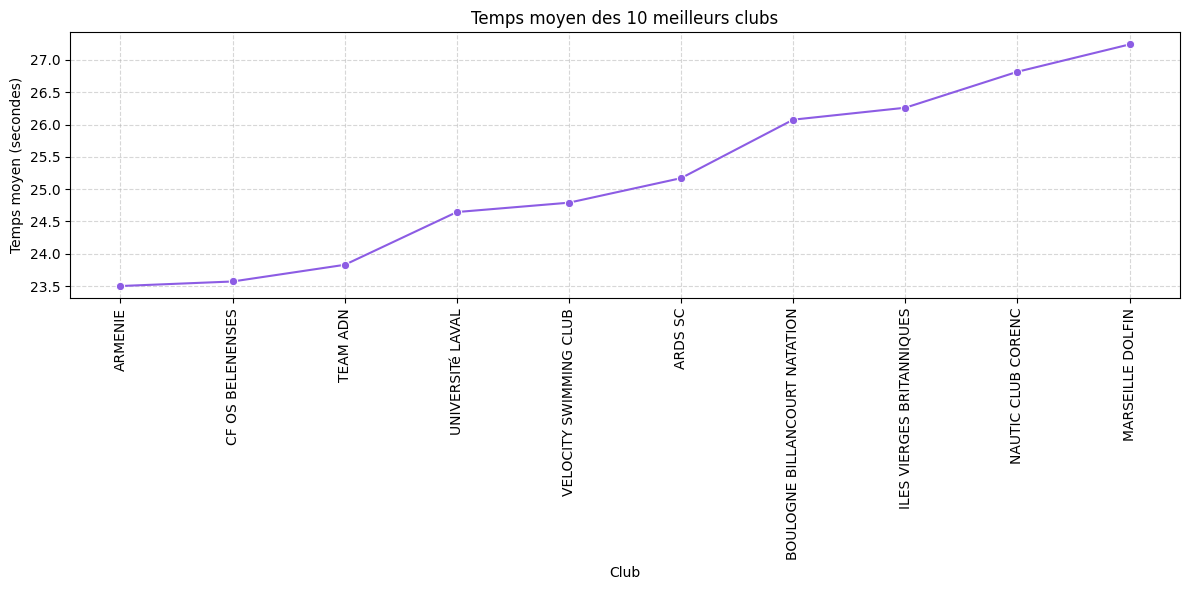

In [18]:
df_time = df[df['SwimTimeSeconds'].notna()]

mean_time_club = df_time.groupby('Club')['SwimTimeSeconds'].mean().reset_index()

mean_time_club = mean_time_club.sort_values('SwimTimeSeconds')

top10_clubs = mean_time_club.head(10)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=top10_clubs,
    x='Club',
    y='SwimTimeSeconds',
    marker='o',
    color="#8C5CE4"
)

plt.title("Temps moyen des 10 meilleurs clubs")
plt.xlabel("Club")
plt.ylabel("Temps moyen (secondes)")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Line Plot of Swim Times by Stroke Type Over Time for a Sample of 5000</h1>

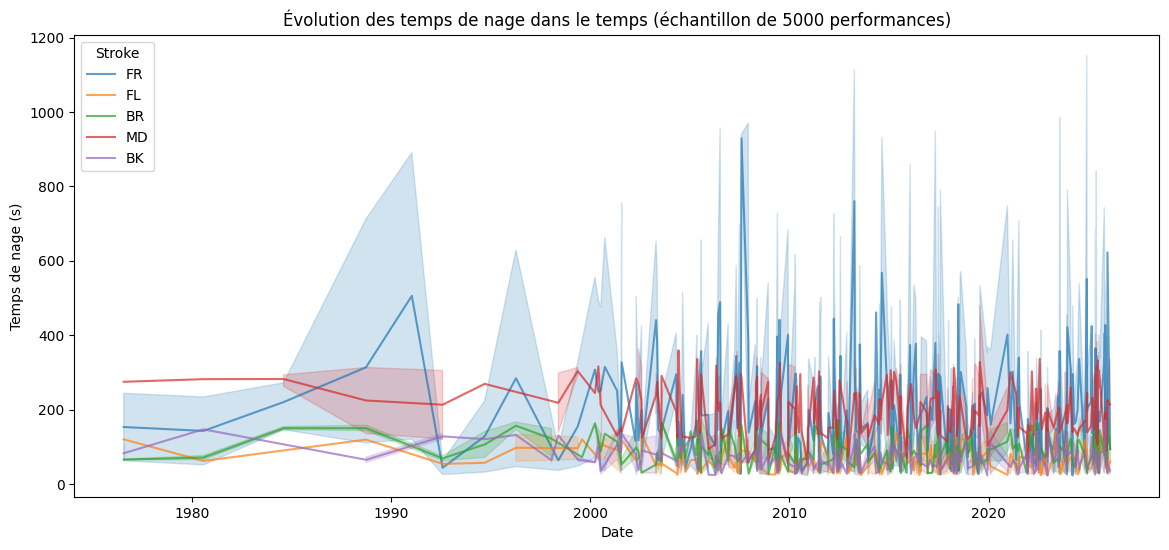

In [20]:
df['SwimDate'] = pd.to_datetime(df['SwimDate'])
plt.figure(figsize=(14,6))
sns.lineplot(x='SwimDate', y='SwimTimeSeconds', data=df.sample(5000), hue='Stroke', alpha=0.7)
plt.title("Évolution des temps de nage dans le temps (échantillon de 5000 performances)")
plt.xlabel("Date")
plt.ylabel("Temps de nage (s)")
plt.legend(title='Stroke')
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Heatmap of Average Swim Times by Distance and Stroke Type</h1>

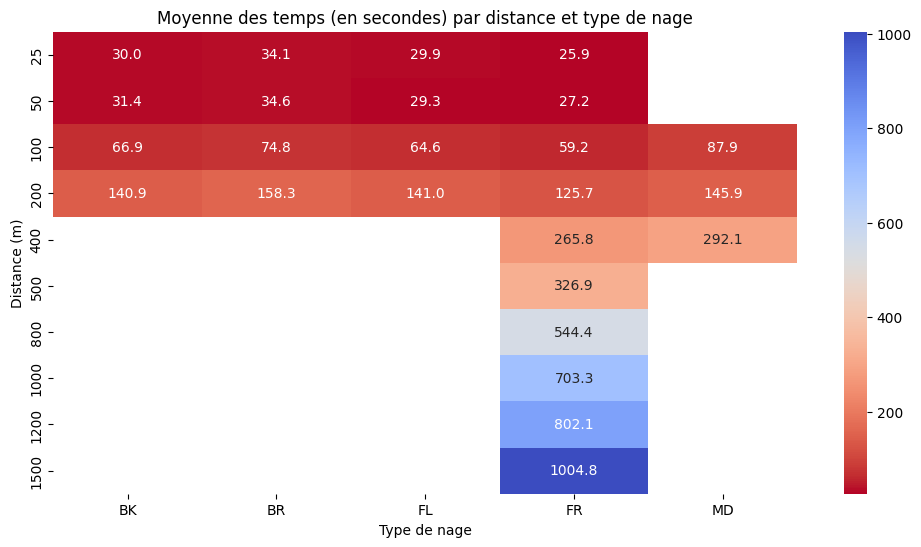

In [21]:
pivot = df.pivot_table(values='SwimTimeSeconds', index='Distance', columns='Stroke', aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm_r")
plt.title("Moyenne des temps (en secondes) par distance et type de nage")
plt.xlabel("Type de nage")
plt.ylabel("Distance (m)")
plt.show()

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2633/1051058208.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


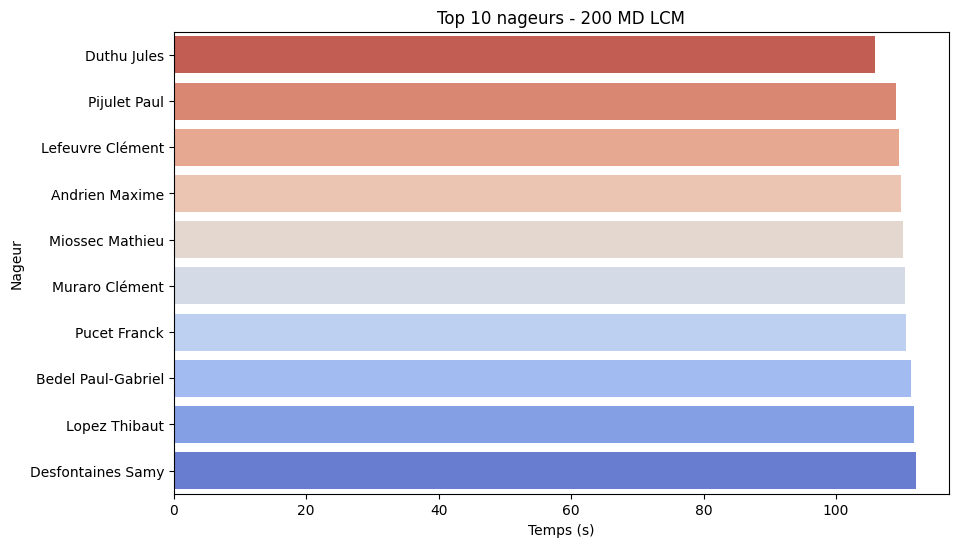

In [78]:
nom_event = "200 MD LCM"

subset = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['SwimTimeSeconds'] > 0)
].copy()

if len(subset) > 0:
    subset['SwimmerName'] = subset['swimmer'].apply(
        lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else "Unknown"
    )

    top10 = subset.nsmallest(10, 'SwimTimeSeconds')

    plt.figure(figsize=(10,6))
    sns.barplot(
        x='SwimTimeSeconds',
        y='SwimmerName',
        data=top10,
        palette="coolwarm_r",
        orient='h'
    )

    plt.title(f"Top 10 nageurs - {nom_event}")
    plt.xlabel("Temps (s)")
    plt.ylabel("Nageur")
    plt.xlim(0, top10['SwimTimeSeconds'].max() + 5)

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

In [29]:
print(df["Distance"].sort_values(ascending=True).unique()) # [  25   50  100  200  400  500  800 1000 1200 1500]

[  25   50  100  200  400  500  800 1000 1200 1500]


<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of Speed Performance Across Distances by Stroke</h1>

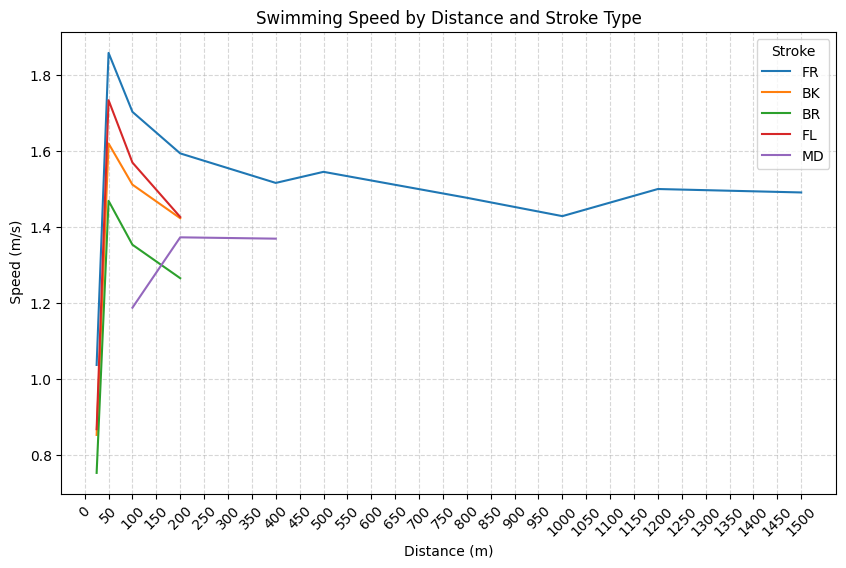

'\nDécroissance rapide de la vitesse \nOn voit que pour toutes les nages, la vitesse chute fortement après 50 m, ce qui est normal physiologiquement (sprint initial vs endurance).\n'

In [23]:
df_speed = df[df['Speed'].notna()]

plt.figure(figsize=(10,6))

sns.lineplot(
    x='Distance',
    y='Speed',
    hue='Stroke',
    data=df_speed,
    errorbar=None
)

max_distance = int(df_speed['Distance'].max())
plt.xticks(np.arange(0, max_distance + 50, 50), rotation=45)

plt.title("Swimming Speed by Distance and Stroke Type")
plt.xlabel("Distance (m)")
plt.ylabel(" Speed (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()
"""
Décroissance rapide de la vitesse 
On voit que pour toutes les nages, la vitesse chute fortement après 50 m, ce qui est normal physiologiquement (sprint initial vs endurance).
"""


Top 10 swimmers for stroke: BK


,Swimmer,SwimTimeSeconds,Distance
681084,"{'Name': 'Chaberty-Baron Marilou', 'Gender': '...",19.75,25
222264,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",22.22,50
35461,"{'Name': 'Lifintsev Miron', 'Gender': 'M', 'Ye...",22.47,50
35462,"{'Name': 'Cooper Isaac', 'Gender': 'M', 'Year_...",22.49,50
24529,"{'Name': 'Cooper Isaac-Alan', 'Gender': 'M', '...",22.52,50
...,...,...,...
658357,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",137.88,200
747788,"{'Name': 'Chaberty-Baron Marilou', 'Gender': '...",160.39,200
412943,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,50
315795,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,100



Top 10 swimmers for stroke: BR


,Swimmer,SwimTimeSeconds,Distance
681108,"{'Name': 'Chaberty-Baron Marilou', 'Gender': '...",20.66,25
308429,"{'Name': 'Malouda Maya', 'Gender': 'F', 'Year_...",24.12,25
24680,"{'Name': 'Fink Nic', 'Gender': 'M', 'Year_of_b...",25.38,50
65169,"{'Name': 'Van Der Burgh Cameron', 'Gender': 'M...",25.41,50
35661,"{'Name': 'Qin Haiyang', 'Gender': 'M', 'Year_o...",25.42,50
...,...,...,...
88928,"{'Name': 'Qin Haiyang', 'Gender': 'M', 'Year_o...",133.35,200
187194,"{'Name': 'Shymanovich Ilya', 'Gender': 'M', 'Y...",133.46,200
90817,"{'Name': 'Shymanovich Ilya', 'Gender': 'M', 'Y...",133.85,200
34090,"{'Name': 'Van Der Burgh Cameron', 'Gender': 'M...",135.10,200



Top 10 swimmers for stroke: FL


,Swimmer,SwimTimeSeconds,Distance
681128,"{'Name': 'Chaberty-Baron Marilou', 'Gender': '...",16.85,25
681029,"{'Name': 'Fusca Alessio', 'Gender': 'M', 'Year...",18.91,25
35901,"{'Name': 'Ponti Non', 'Gender': 'M', 'Year_of_...",21.32,50
35909,"{'Name': 'Ponti Non', 'Gender': 'M', 'Year_of_...",21.43,50
18266,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",21.51,50
...,...,...,...
28990,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",122.19,200
171566,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",124.19,200
171590,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",124.65,200
433103,"{'Name': 'Grousset Maxime', 'Gender': 'M', 'Ye...",NaN,50



Top 10 swimmers for stroke: FR


,Swimmer,SwimTimeSeconds,Distance
182140,"{'Name': 'Hindley Isabella', 'Gender': 'F', 'Y...",0.00,100
664830,"{'Name': 'Penet Anatole', 'Gender': 'M', 'Year...",0.00,50
681059,"{'Name': 'Chaberty-Baron Marilou', 'Gender': '...",15.23,25
680966,"{'Name': 'Fusca Alessio', 'Gender': 'M', 'Year...",16.70,25
681060,"{'Name': 'Cirillo Erin', 'Gender': 'F', 'Year_...",18.71,25
...,...,...,...
452474,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,100
515662,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,100
557989,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,100
607404,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,100



Top 10 swimmers for stroke: MD


,Swimmer,SwimTimeSeconds,Distance
36149,"{'Name': 'Ponti Non', 'Gender': 'M', 'Year_of_...",50.33,100
36157,"{'Name': 'Ponti Non', 'Gender': 'M', 'Year_of_...",50.43,100
18471,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",50.52,100
18472,"{'Name': 'Grousset Maxime', 'Gender': 'M', 'Ye...",50.53,100
656328,"{'Name': 'Grousset Maxime', 'Gender': 'M', 'Ye...",50.56,100
...,...,...,...
140611,"{'Name': 'Lochte Ryan', 'Gender': 'M', 'Year_o...",257.26,400
605595,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",259.35,400
179328,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",262.93,400
179341,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",265.42,400


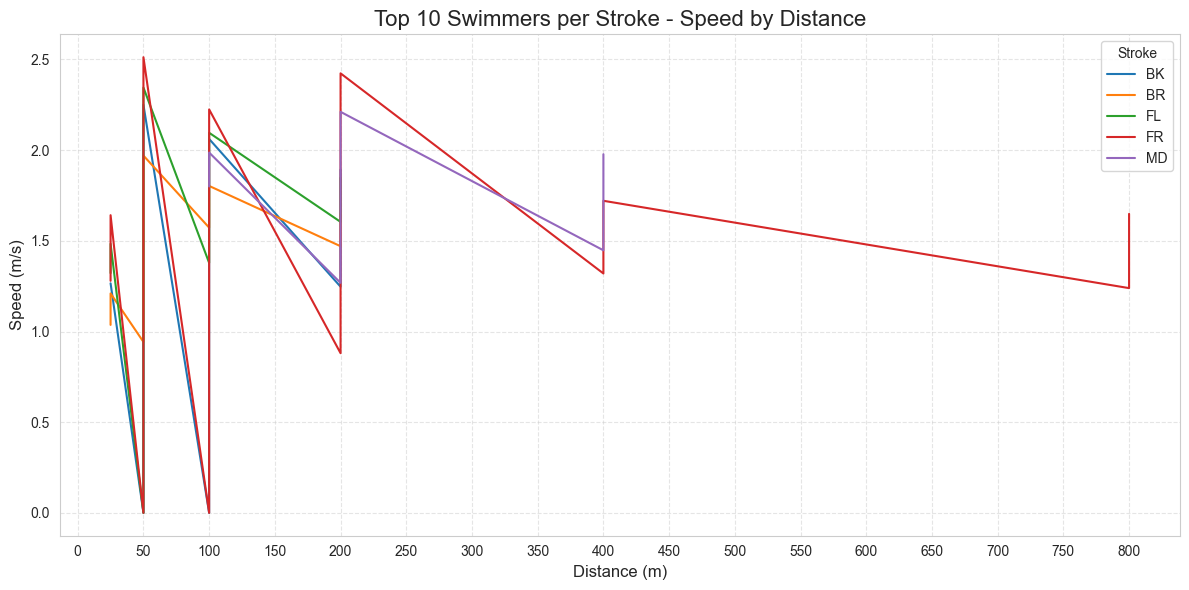

In [ ]:
import mplcursors

df_clean = df[df['Speed'].notna()]

def clean_swimmer(x):
    if isinstance(x, dict):
        return x.get('Name', str(x))
    elif isinstance(x, list) and len(x) > 0:
        return str(x[0])
    else:
        return str(x)
df_clean['Swimmer'] = df_clean['swimmer'].apply(clean_swimmer)

df_clean = df_clean.sort_values(by=['Stroke', 'Swimmer', 'Distance'])

top_swimmers = pd.DataFrame()
for stroke in df_clean['Stroke'].unique():
    df_s = df_clean[df_clean['Stroke'] == stroke].sort_values('SwimTimeSeconds')
    top10 = df_s['Swimmer'].drop_duplicates().head(10)
    top_swimmers = pd.concat([top_swimmers, df_s[df_s['Swimmer'].isin(top10)]])

for stroke in top_swimmers['Stroke'].unique():
    print(f"\nTop 10 swimmers for stroke: {stroke}")
    display(top_swimmers[top_swimmers['Stroke'] == stroke][['Swimmer','SwimTimeSeconds','Distance']])

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

ax = sns.lineplot(
    x='Distance',
    y='Speed',
    hue='Stroke',
    data=top_swimmers,
    markers=True,
    dashes=False,
    estimator=None
)

max_distance = int(top_swimmers['Distance'].max())
plt.xticks(np.arange(0, max_distance + 50, 50))  # pas de 50 m

points = list(zip(top_swimmers['Distance'], top_swimmers['Speed'], top_swimmers['Swimmer']))
cursor = mplcursors.cursor(ax.lines, hover=True)

@cursor.connect("add")
def on_add(sel):
    x_data, y_data = sel.target
    nearest = min(points, key=lambda p: (p[0]-x_data)**2 + (p[1]-y_data)**2)
    sel.annotation.set_text(f"{nearest[2]}\nSpeed: {nearest[1]:.2f} m/s\nDistance: {nearest[0]} m")

plt.title("Top 10 Swimmers per Stroke - Speed by Distance", fontsize=16)
plt.xlabel("Distance (m)", fontsize=12)
plt.ylabel("Speed (m/s)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Heatmap of Average Swim Speed by Distance and Stroke</h1>

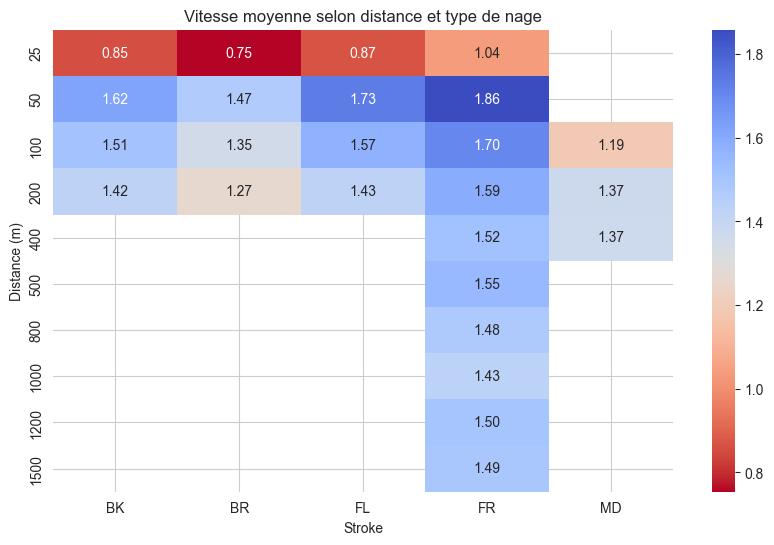

In [25]:
pivot = df.pivot_table(
    values='Speed',
    index='Distance',
    columns='Stroke',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm_r",
    fmt=".2f"
)

plt.title("Vitesse moyenne selon distance et type de nage")
plt.xlabel("Stroke")
plt.ylabel("Distance (m)")

plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of Speed ​​per split for a precise Swimmer and Event</h1>

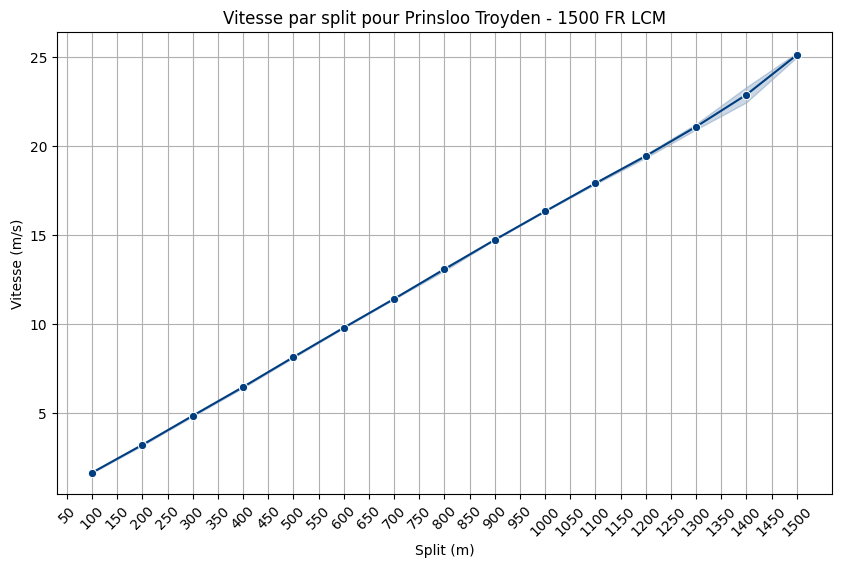

In [60]:
nom_nageur = "Prinsloo Troyden"
nom_event = "1500 FR LCM"

split_data = []
gender_nageur = None  

for idx, row in df.iterrows():
    if row['Event'] == nom_event and len(row['swimmer']) == 1:
        swimmer = row['swimmer'][0]
        if swimmer['Name'] == nom_nageur:
            gender_nageur = swimmer['Gender']  
            for s in row['splits']:
                if s['split_speed'] is not None:
                    dist = int(s['split_distance'].replace(' m',''))
                    split_data.append({
                        'split_distance': dist,
                        'split_speed': s['split_speed']
                    })

df_splits = pd.DataFrame(split_data)

df_splits = df_splits.sort_values('split_distance')

if gender_nageur == "M":
    color_line = "#003E80"  
elif gender_nageur == "F":
    color_line = "#FF69B4"  
else:
    color_line = "#008080"  

plt.figure(figsize=(10,6))
sns.lineplot(
    x='split_distance',
    y='split_speed',
    data=df_splits,
    marker='o',
    color=color_line
)
plt.xticks(range(50, df_splits['split_distance'].max()+50, 50), rotation = 45) 
plt.title(f"Vitesse par split pour {nom_nageur} - {nom_event}")
plt.xlabel("Split (m)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True)
plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmers for a specific event</h1>

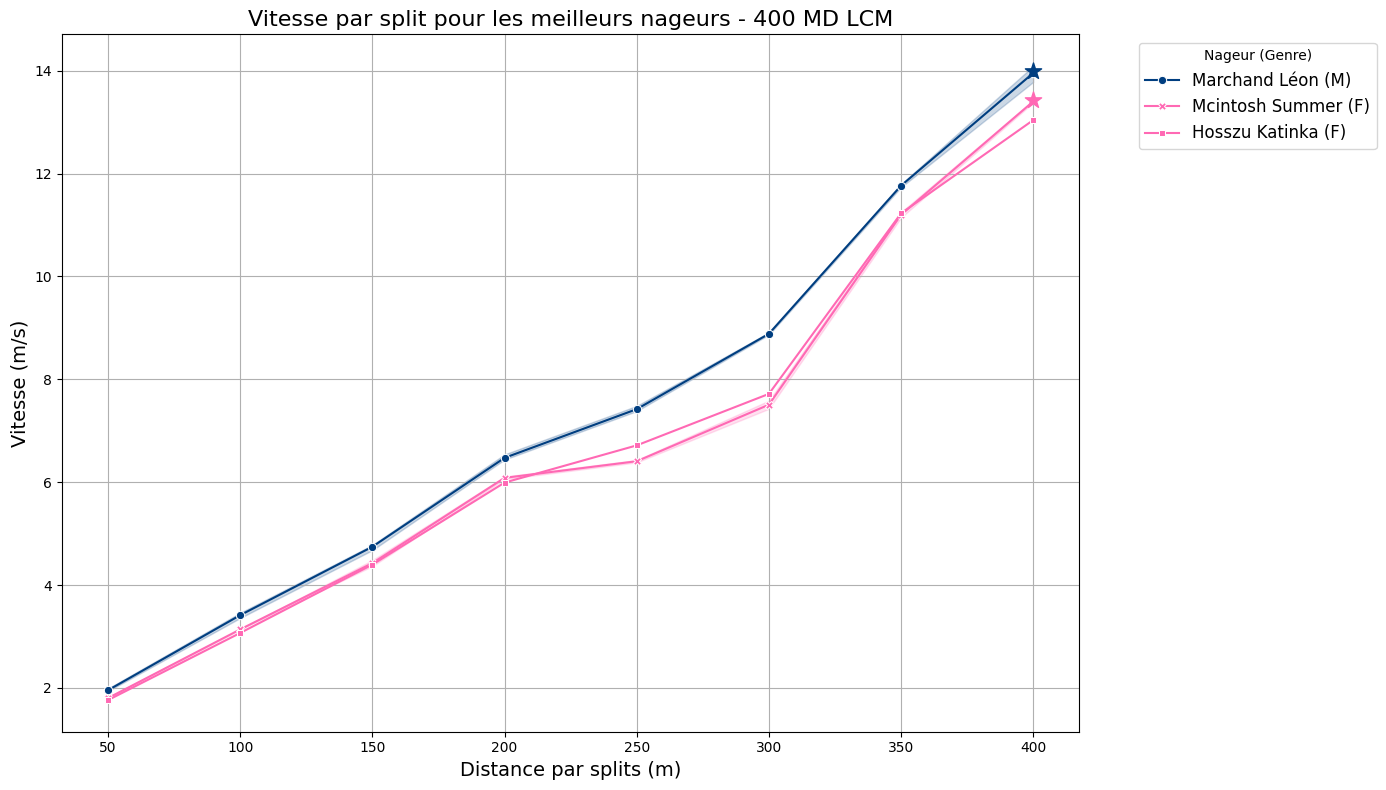

In [64]:
nom_event = "400 MD LCM"
top_n = 3  

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')

df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    swimmer_name = row['swimmer_name']
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_speed'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'swimmer': swimmer_name,
                    'gender': gender,
                    'split_distance': dist,
                    'split_speed': s['split_speed']
                })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucun split valide trouvé pour les top nageurs.")
else:
    df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'] + ")"

    palette_colors = {'M': "#003E80", 'F': "#FF69B4"}
    palette_for_plot = {label: palette_colors[gender] for label, gender in zip(df_splits['swimmer_label'], df_splits['gender'])}

    plt.figure(figsize=(14,8))
    sns.lineplot(
        x='split_distance',
        y='split_speed',
        hue='swimmer_label',
        style='swimmer_label',
        data=df_splits,
        markers=True,
        dashes=False,
        palette=palette_for_plot
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour les meilleurs nageurs - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

    best_male = df_top_men.nsmallest(1, 'SwimTimeSeconds')['swimmer_name'].values[0]
    best_female = df_top_women.nsmallest(1, 'SwimTimeSeconds')['swimmer_name'].values[0]

    for swimmer in [best_male, best_female]:
        swimmer_data = df_splits[df_splits['swimmer'] == swimmer]
        color = palette_for_plot[swimmer + f" ({swimmer_data['gender'].iloc[0]})"]

        plt.scatter(
            swimmer_data['split_distance'].iloc[-1],
            swimmer_data['split_speed'].iloc[-1],
            s=150,  
            color=color,
            marker='*',
            zorder=5
        )

    plt.tight_layout()
    plt.show()

In [ ]:
df_event = df[
    (df['Event'] == "1500 FR LCM") &
    (df['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1) &
     df['splits'].apply(lambda x: isinstance(x, list) and len(x) == 15))
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

swimmers_in_event = df_event[['swimmer_name', 'swimmer_gender']].drop_duplicates()

print(len(swimmers_in_event))
# y a des nageurs qui n ont pas tous les splits

3472


<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmers for a specific event (women vs men)</h1>

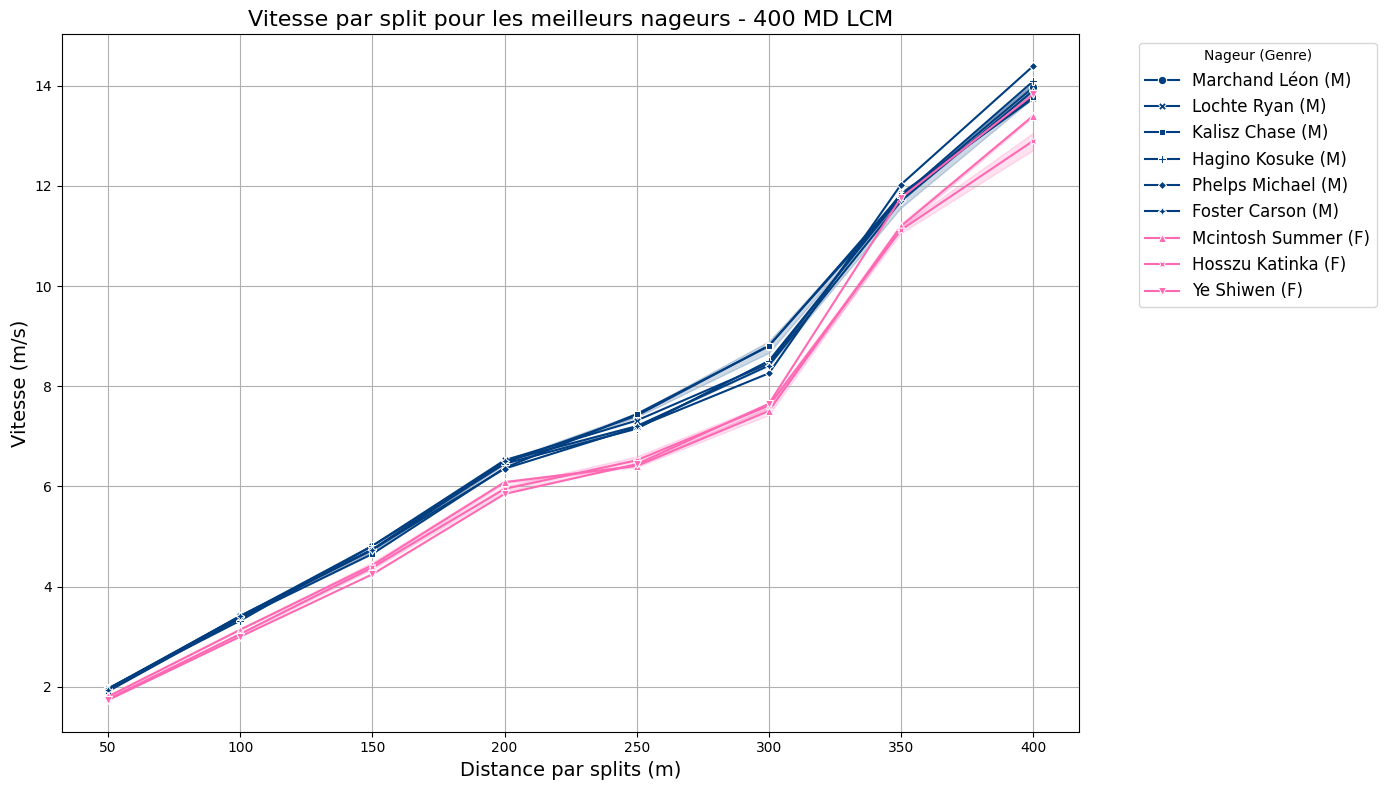

In [73]:
nom_event = "400 MD LCM"  
top_n = 10                

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')

df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    swimmer_name = row['swimmer_name']
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits: 
        for s in splits:
            if s['split_speed'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'swimmer': swimmer_name,
                    'gender': gender,
                    'split_distance': dist,
                    'split_speed': s['split_speed']
                })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucun split valide trouvé pour les top nageurs.")
else:
    df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'] + ")"

    palette_colors = {'M': "#003E80", 'F': "#FF69B4"}

    palette_for_plot = {label: palette_colors[gender] for label, gender in zip(df_splits['swimmer_label'], df_splits['gender'])}

    plt.figure(figsize=(14,8))
    sns.lineplot(
        x='split_distance',
        y='split_speed',
        hue='swimmer_label',
        style='swimmer_label',
        data=df_splits,
        markers=True,
        dashes=False,
        palette=palette_for_plot
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour les meilleurs nageurs - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of split speed for the best swimmer in a given event</h1>

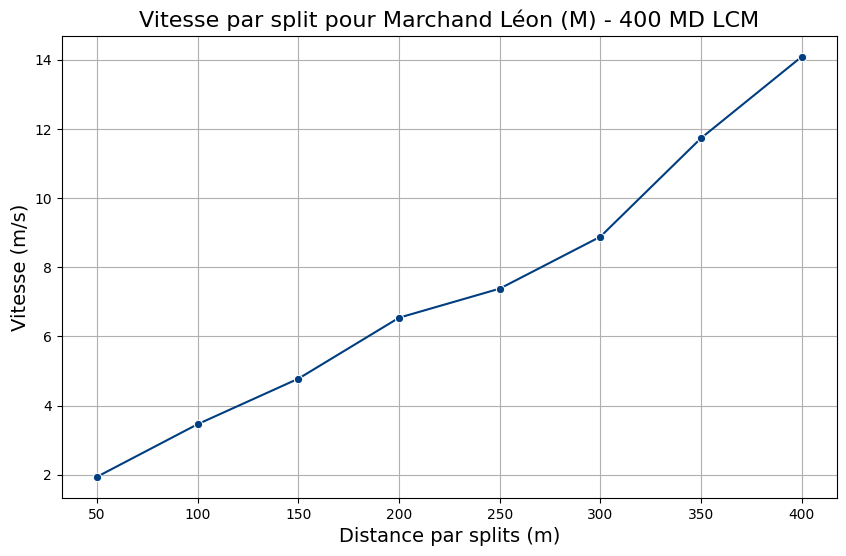

In [66]:
nom_event = "400 MD LCM"

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_best = df_event.nsmallest(1, 'SwimTimeSeconds').iloc[0]

best_name = df_best['swimmer_name']
best_gender = df_best['swimmer_gender']
best_splits = df_best['splits']

split_data = []
for s in best_splits:
    if s['split_speed'] is not None:
        dist = int(s['split_distance'].replace(' m',''))
        split_data.append({
            'split_distance': dist,
            'split_speed': s['split_speed']
        })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print(f"Aucun split valide trouvé pour le meilleur nageur de l'Event {nom_event}.")
else:
    plt.figure(figsize=(10,6))
    color = "#003E80" if best_gender == 'M' else "#FF69B4"

    sns.lineplot(
        x='split_distance',
        y='split_speed',
        data=df_splits,
        marker='o',
        color=color
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour {best_name} ({best_gender}) - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.show()

<h1 style="color:#F0B4B4; font-size:32px;">Lineplot of average of swim time by splits</h1>

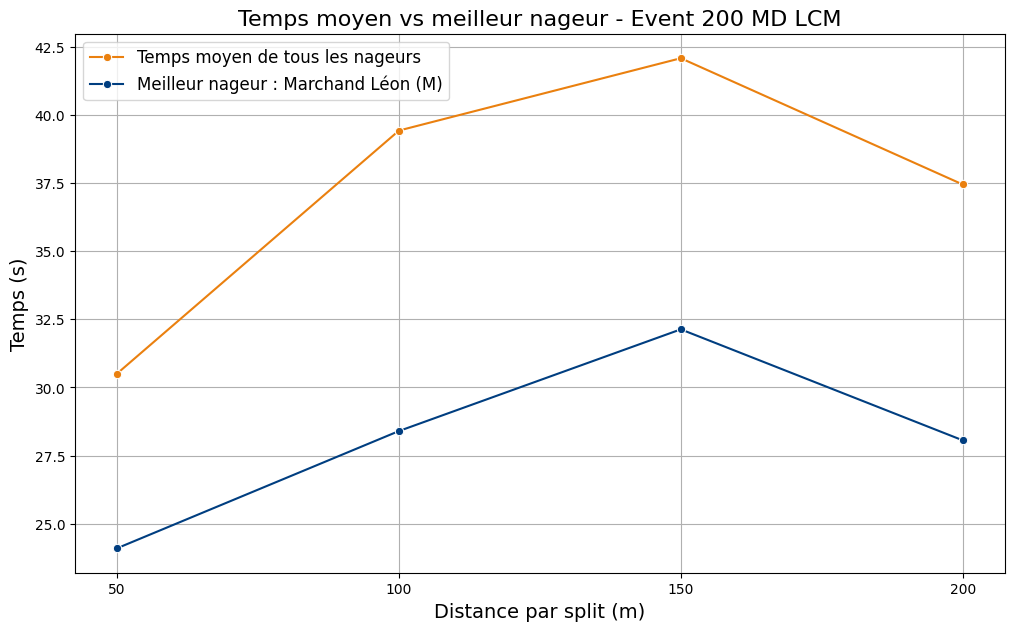

In [67]:
nom_event = "200 MD LCM"  
df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_mean_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

df_best = df_event.nsmallest(1, 'SwimTimeSeconds').iloc[0]
best_name = df_best['swimmer'][0]['Name']
best_gender = df_best['swimmer'][0]['Gender']
best_splits = df_best['splits']

split_best_data = []
for s in best_splits:
    if s['split_seconds'] is not None:
        dist = int(s['split_distance'].replace(' m',''))
        split_best_data.append({
            'split_distance': dist,
            'split_seconds': s['split_seconds']
        })

df_best_splits = pd.DataFrame(split_best_data)

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_mean_splits,
    marker='o',
    color="#EA800F",
    label="Temps moyen de tous les nageurs"
)

color_best = "#003E80" if best_gender == 'M' else "#FF69B4"
sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_best_splits,
    marker='o',
    color=color_best,
    label=f"Meilleur nageur : {best_name} ({best_gender})"
)

plt.xticks(range(50, max(df_mean_splits['split_distance'].max(), df_best_splits['split_distance'].max())+50, 50))
plt.title(f"Temps moyen vs meilleur nageur - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

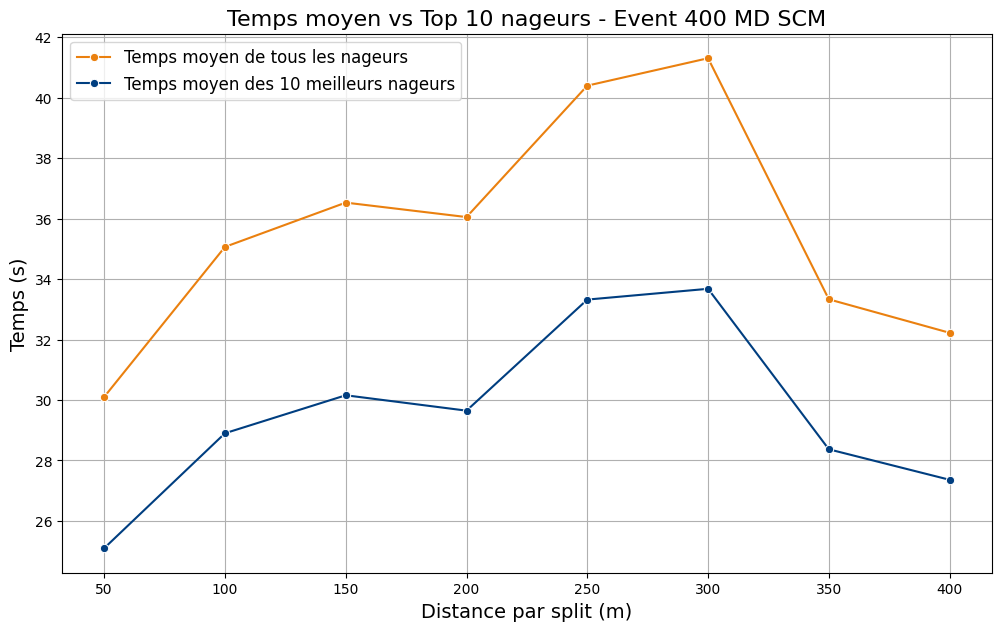

In [68]:
nom_event = "400 MD SCM"

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_mean_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

df_top10 = df_event.nsmallest(10, 'SwimTimeSeconds')

top10_split_data = []

for idx, row in df_top10.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                top10_split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_top10_splits = pd.DataFrame(top10_split_data)

df_top10_mean = df_top10_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_mean_splits,
    marker='o',
    color="#EA800F",
    label="Temps moyen de tous les nageurs"
)

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_top10_mean,
    marker='o',
    color="#003E80",
    label="Temps moyen des 10 meilleurs nageurs"
)

plt.xticks(range(50, max(df_mean_splits['split_distance'].max(),
                         df_top10_mean['split_distance'].max()) + 50, 50))

plt.title(f"Temps moyen vs Top 10 nageurs - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)

plt.grid(True)
plt.legend(fontsize=12)

plt.show()

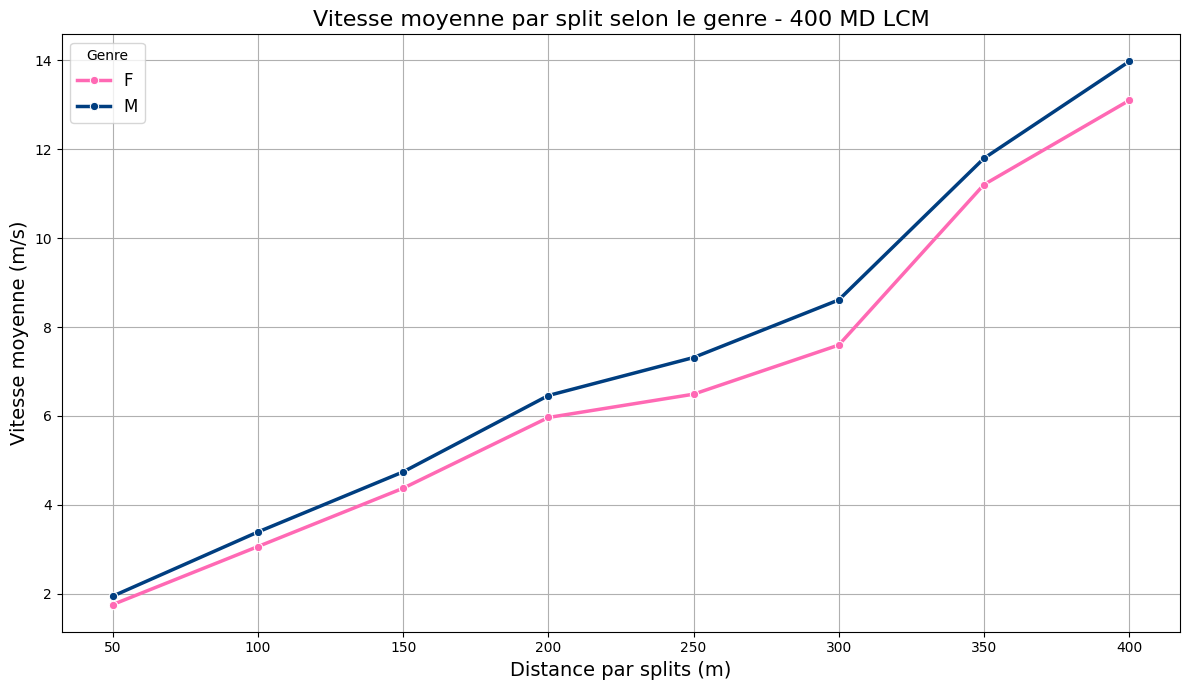

In [69]:
nom_event = "400 MD LCM"  
top_n = 10                

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits:
        for s in splits:
            dist = int(s['split_distance'].replace(' m',''))
            split_speed = s['split_speed'] if s['split_speed'] is not None else float('nan')
            split_data.append({
                'gender': gender,
                'split_distance': dist,
                'split_speed': split_speed
            })

df_splits = pd.DataFrame(split_data)

df_avg = df_splits.groupby(['gender', 'split_distance'])['split_speed'].mean().reset_index()

plt.figure(figsize=(12,7))
palette_colors = {'M': "#003E80", 'F': "#FF69B4"}

sns.lineplot(
    x='split_distance',
    y='split_speed',
    hue='gender',
    data=df_avg,
    marker='o',
    palette=palette_colors,
    linewidth=2.5
)

plt.xticks(range(50, int(df_splits['split_distance'].max())+50, 50))
plt.title(f"Vitesse moyenne par split selon le genre - {nom_event}", fontsize=16)
plt.xlabel("Distance par splits (m)", fontsize=14)
plt.ylabel("Vitesse moyenne (m/s)", fontsize=14)
plt.grid(True)
plt.legend(title='Genre', fontsize=12)
plt.tight_layout()
plt.show()

In [70]:
print(df["Event"].unique()) 

['200 FR SCM' '400 FR SCM' '50 BK SCM' '200 BK SCM' '50 BR SCM'
 '200 BR SCM' '50 FL SCM' '200 FL SCM' '200 MD SCM' '400 MD SCM'
 '500 FR SCM' '1000 FR SCM' '100 FR SCM' '100 BK SCM' '100 BR SCM'
 '100 FL SCM' '800 FR SCM' '50 FR SCM' '1500 FR SCM' '100 MD SCM'
 '50 FR LCM' '100 FR LCM' '200 FR LCM' '400 FR LCM' '800 FR LCM'
 '50 BK LCM' '100 BK LCM' '200 BK LCM' '50 BR LCM' '100 BR LCM'
 '200 BR LCM' '50 FL LCM' '100 FL LCM' '200 FL LCM' '200 MD LCM'
 '400 MD LCM' '1500 FR LCM' '25 BR SCM' '25 FR SCM' '25 BK SCM'
 '25 FL SCM' '1200 FR LCM' '500 FR LCM' '1000 FR LCM']


In [ ]:
nom_event = "200 FR LCM"

df_filtered = df[
    (df['Event'] == nom_event) &
    (df['swimmer'].apply(len) == 1) &
    (df['splits'].apply(lambda x: isinstance(x, list) and len(x) > 0))
]

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print(df_filtered.shape)
print(df_filtered.swimmer)

(35578, 21)
12081                         [{'Name': 'Van Almsick Franziska', 'Gender': 'F', 'Year_of_birth': 1978, 'Nationality': 'GER'}]
12082                                 [{'Name': 'Potec Camelia', 'Gender': 'F', 'Year_of_birth': 1982, 'Nationality': 'ROU'}]
12083                            [{'Name': 'Popchanka Alena V.', 'Gender': 'F', 'Year_of_birth': 1979, 'Nationality': 'BLR'}]
12084                [{'Name': 'Figues De Sainte Marie Solenne', 'Gender': 'F', 'Year_of_birth': 1979, 'Nationality': 'FRA'}]
12085                                    [{'Name': 'Roca Laura', 'Gender': 'F', 'Year_of_birth': 1980, 'Nationality': 'ESP'}]
12086                                 [{'Name': 'Rouba Tatiana', 'Gender': 'F', 'Year_of_birth': 1983, 'Nationality': 'ESP'}]
12087                           [{'Name': 'Hjorth Hansen Julie', 'Gender': 'F', 'Year_of_birth': 1984, 'Nationality': 'DEN'}]
12088                             [{'Name': 'Van Rooijen Manon', 'Gender': 'F', 'Year_of_birth': 1982, 'Na

In [72]:
df_filtered = df[
    (df['splits'].apply(lambda x: isinstance(x, list) and len(x) > 0)) &
    (df['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1))
]

events_filtered = df_filtered['Event'].unique()

print(len(events_filtered))

26


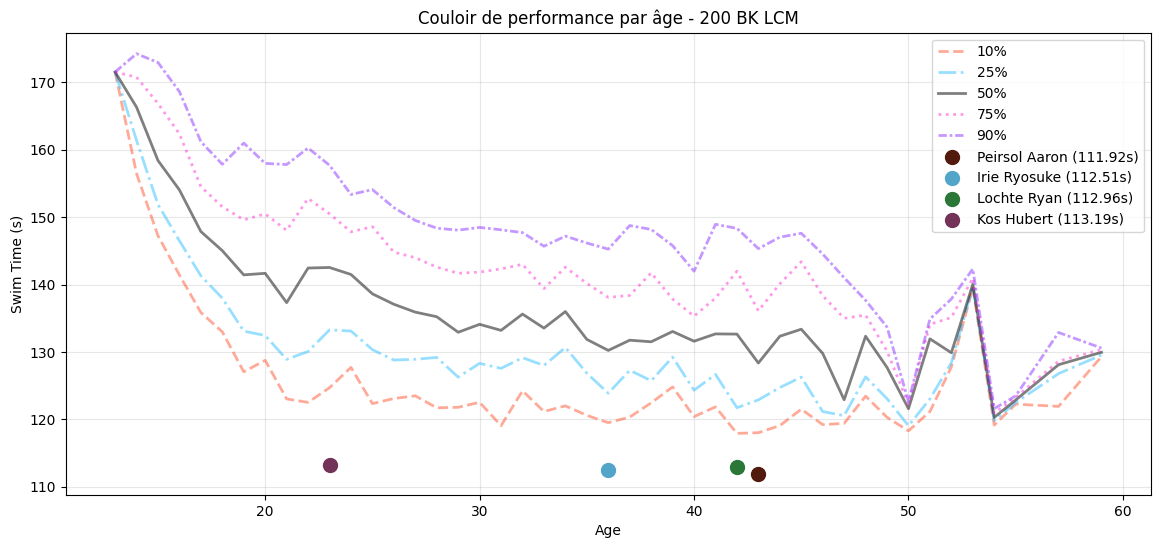

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fonction pour extraire l'année de naissance du nageur
def get_birth_year(swimmer):
    if isinstance(swimmer, list) and len(swimmer) > 0 and isinstance(swimmer[0], dict) and "Year_of_birth" in swimmer[0]:
        return swimmer[0]["Year_of_birth"]
    return None

# Filtrer l'event et garder les lignes valides
df_event = df[
    (df["Event"] == "200 BK LCM") &
    (df["SwimTimeSeconds"].notna()) &
    (df["splits"].apply(lambda x: isinstance(x, list) and len(x) > 0))
].copy()

# Ajouter Year_of_birth et Age
df_event['Year_of_birth'] = df_event['swimmer'].apply(get_birth_year)
df_event = df_event[df_event['Year_of_birth'].notna()]
df_event['Age'] = 2026 - df_event['Year_of_birth']

# Calcul des percentiles par âge
ages = sorted(df_event['Age'].unique())
percentiles = [10, 25, 50, 75, 90]
percentile_curves = {p: [] for p in percentiles}

for age in ages:
    swim_times = df_event[df_event['Age'] == age]['SwimTimeSeconds'].values
    for p in percentiles:
        percentile_curves[p].append(np.percentile(swim_times, p) if len(swim_times) > 0 else np.nan)

# Top 4 nageurs uniques selon la performance
df_event_sorted = df_event.sort_values("SwimTimeSeconds")
top_unique = df_event_sorted.groupby(lambda x: df_event_sorted.loc[x, "swimmer"][0]["Name"]).first()
top_4_unique = top_unique.nsmallest(4, "SwimTimeSeconds").copy()

swimmers_to_follow = ["Popovici David", "Alexy Jack"] 

percentile_colors = {10: "#FF5733", 25: "#33C1FF", 50: "#000000", 75: "#FF33D4", 90: "#8D33FF"}
percentile_styles = {10: "--", 25: "-.", 50: "-", 75: ":", 90: (0, (3, 1, 1, 1))}

plt.figure(figsize=(14, 6))

for p in percentiles:
    plt.plot(
        ages, 
        percentile_curves[p], 
        linestyle=percentile_styles[p], 
        label=f'{p}%', 
        color=percentile_colors[p], 
        alpha=0.5,
        linewidth=2
    )

# Tracer top 4 nageurs uniques
colors_top4 = ["#521A0D", "#52A5C9", "#2A7738", "#733257"]
for i, row in enumerate(top_4_unique.itertuples()):
    age = 2026 - row.Year_of_birth
    plt.scatter(age, row.SwimTimeSeconds, color=colors_top4[i % len(colors_top4)], s=100,
                label=f"{row.swimmer[0]['Name']} ({row.SwimTimeSeconds:.2f}s)")

# Tracer les nageurs à suivre avec marqueur spécial
follow_colors = ["#FF0000", "#FFA500", "#00FF00", "#00FFFF"]  # couleurs pour suivi
for i, name in enumerate(swimmers_to_follow):
    swimmer_rows = df_event[df_event['swimmer'].apply(lambda x: x[0]['Name'] == name)]
    for row in swimmer_rows.itertuples():
        age = 2026 - row.Year_of_birth
        plt.scatter(age, row.SwimTimeSeconds, color=follow_colors[i % len(follow_colors)], 
                    s=150, edgecolor='black', linewidth=1.5,
                    label=f"Suivi: {name} ({row.SwimTimeSeconds:.2f}s)")

plt.xlabel("Age")
plt.ylabel("Swim Time (s)")
plt.title("Couloir de performance par âge - 200 BK LCM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [65]:
df['swimmer_name'] = df['swimmer'].apply(
    lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else None
)

participations = df.groupby(['swimmer_name', 'Event']).size().reset_index(name='count')

recurrent_swimmers = participations[participations['count'] > 1]

noms_recurrents = recurrent_swimmers['swimmer_name'].unique()

print(noms_recurrents[:10])

['Aabkari Reyan' 'Aaltomaa Sami' 'Aarab Amine' 'Aartsen Stefan'
 'Aastedt Sofia' 'Abad Christophe' 'Abadie Aimée' 'Abadie Camille'
 'Abagnale Michele' 'Abal Pablo']
